In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)



import pandas as pd
from utils.graph import dag_to_cpdag
import ast
# from metrics.graph import compare_dags
from utils.results import *
from synthetic.binary import *
from utils.plotting import *

In [2]:
import json
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple, Any

import numpy as np
import pandas as pd
import networkx as nx


# ----------------------------
# Spec (structure + CPD params)
# ----------------------------
@dataclass(frozen=True)
class BinaryDAGSpec:
    n_nodes: int
    topo_order: Tuple[int, ...]                 # a topological order used during sampling
    edges: Tuple[Tuple[int, int], ...]          # (u, v)
    node_cpd: Tuple[Dict[str, Any], ...]        # length n_nodes; each entry JSON-able

    def to_dict(self) -> Dict[str, Any]:
        return {
            "n_nodes": int(self.n_nodes),
            "topo_order": list(map(int, self.topo_order)),
            "edges": [[int(u), int(v)] for (u, v) in self.edges],
            "node_cpd": self.node_cpd,  # already JSON-able dicts/lists/numbers
        }

    @staticmethod
    def from_dict(d: Dict[str, Any]) -> "BinaryDAGSpec":
        return BinaryDAGSpec(
            n_nodes=int(d["n_nodes"]),
            topo_order=tuple(map(int, d["topo_order"])),
            edges=tuple((int(u), int(v)) for u, v in d["edges"]),
            node_cpd=tuple(d["node_cpd"]),
        )

    def save_json(self, path: str) -> None:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.to_dict(), f, indent=2)

    @staticmethod
    def load_json(path: str) -> "BinaryDAGSpec":
        with open(path, "r", encoding="utf-8") as f:
            return BinaryDAGSpec.from_dict(json.load(f))


# ----------------------------
# DAG samplers
# ----------------------------
def sample_er_dag(
    n_nodes: int,
    p_edge: float,
    max_indeg: Optional[int] = None,
    seed: int = 0,
) -> Tuple[Tuple[int, ...], Tuple[Tuple[int, int], ...]]:
    """
    ER DAG: sample a random topological order pi, then for each i<j in that order,
    add edge pi[i] -> pi[j] with probability p_edge. Optionally cap in-degree.
    """
    rng = np.random.default_rng(seed)
    topo = rng.permutation(n_nodes).tolist()
    indeg = {v: 0 for v in range(n_nodes)}
    edges: List[Tuple[int, int]] = []

    for i in range(n_nodes):
        u = topo[i]
        for j in range(i + 1, n_nodes):
            v = topo[j]
            if rng.random() < p_edge:
                if max_indeg is None or indeg[v] < max_indeg:
                    edges.append((u, v))
                    indeg[v] += 1

    return tuple(topo), tuple(edges)


def sample_ba_dag(
    n_nodes: int,
    m_parents: int = 2,
    seed: int = 0,
) -> Tuple[Tuple[int, ...], Tuple[Tuple[int, int], ...]]:
    """
    Scale-free-ish DAG: nodes arrive in a random order; each new node chooses m_parents
    from previous nodes with probability proportional to (degree + 1). Orient old -> new.
    """
    rng = np.random.default_rng(seed)
    topo = rng.permutation(n_nodes).tolist()

    # start with first node having no parents
    edges: List[Tuple[int, int]] = []
    degree = {topo[0]: 0}

    for t in range(1, n_nodes):
        v = topo[t]
        prev = topo[:t]
        # weights proportional to degree+1 to avoid zeros
        w = np.array([degree.get(u, 0) + 1 for u in prev], dtype=float)
        w = w / w.sum()

        m = min(m_parents, len(prev))
        parents = rng.choice(prev, size=m, replace=False, p=w).tolist()
        for u in parents:
            edges.append((u, v))
            degree[u] = degree.get(u, 0) + 1
        degree[v] = degree.get(v, 0) + len(parents)

    return tuple(topo), tuple(edges)


def sample_ws_dag(
    n_nodes: int,
    k: int = 4,
    beta: float = 0.2,
    seed: int = 0,
) -> Tuple[Tuple[int, ...], Tuple[Tuple[int, int], ...]]:
    """
    Small-world-ish DAG:
      1) Build undirected ring lattice with degree k (k must be even)
      2) Rewire edges with prob beta (Watts-Strogatz style)
      3) Choose a random topo order and orient each undirected edge low->high in that order
    """
    if k % 2 != 0:
        raise ValueError("k must be even for ring lattice.")
    rng = np.random.default_rng(seed)

    # Build undirected ring lattice edges
    undirected = set()
    for i in range(n_nodes):
        for d in range(1, k // 2 + 1):
            j = (i + d) % n_nodes
            a, b = min(i, j), max(i, j)
            undirected.add((a, b))

    undirected = list(undirected)

    # Rewire: for each edge (u,v) with u fixed, rewire v to a random node not u and not already connected
    undirected_set = set(undirected)
    rewired = set()
    for (u, v) in undirected:
        if rng.random() < beta:
            # remove old
            undirected_set.discard((u, v))
            # pick new endpoint
            candidates = [x for x in range(n_nodes) if x != u]
            rng.shuffle(candidates)
            for w in candidates:
                a, b = min(u, w), max(u, w)
                if (a, b) not in undirected_set and (a, b) not in rewired:
                    rewired.add((a, b))
                    break
        else:
            # keep
            pass

    undirected_set |= rewired
    undirected = list(undirected_set)

    topo = rng.permutation(n_nodes).tolist()
    pos = {node: i for i, node in enumerate(topo)}

    edges: List[Tuple[int, int]] = []
    for (a, b) in undirected:
        # orient from earlier in topo to later in topo
        u, v = (a, b) if pos[a] < pos[b] else (b, a)
        edges.append((u, v))

    return tuple(topo), tuple(edges)


# ----------------------------
# CPD + simulation
# ----------------------------
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def make_cpds_for_dag(
    dag: nx.DiGraph,
    model: str = "logistic",       # "logistic" or "noisy_or"
    seed: int = 0,
    root_p: float = 0.5,
    weight_scale: float = 1.0,
) -> List[Dict[str, Any]]:
    """
    Create per-node CPD params (JSON-able). Parents are taken from dag.
    """
    rng = np.random.default_rng(seed)
    n_nodes = dag.number_of_nodes()
    cpds: List[Dict[str, Any]] = [None] * n_nodes

    for v in range(n_nodes):
        parents = sorted(list(dag.predecessors(v)))
        if len(parents) == 0:
            cpds[v] = {"model": "root", "p": float(root_p), "parents": parents}
        else:
            if model == "logistic":
                w = (rng.normal(0.0, weight_scale, size=len(parents))).tolist()
                b = float(rng.normal(0.0, 0.5))
                cpds[v] = {"model": "logistic", "parents": parents, "w": w, "b": b}
            elif model == "noisy_or":
                # link probs for each parent + leak
                link = rng.uniform(0.1, 0.6, size=len(parents)).tolist()
                leak = float(rng.uniform(0.01, 0.10))
                cpds[v] = {"model": "noisy_or", "parents": parents, "link": link, "leak": leak}
            else:
                raise ValueError(f"Unknown model: {model}")

    return cpds


def simulate_from_spec(
    spec: BinaryDAGSpec,
    n_samples: int,
    seed: int = 0,
    p_flip: float = 0.0,
) -> Tuple[pd.DataFrame, nx.DiGraph, pd.DataFrame]:
    """
    Simulate binary data from a (structure + CPDs) spec.
    """
    rng = np.random.default_rng(seed)

    dag = nx.DiGraph()
    dag.add_nodes_from(range(spec.n_nodes))
    dag.add_edges_from(spec.edges)

    # Use the stored topo_order (already a topo order by construction)
    topo = list(spec.topo_order)

    X = np.zeros((n_samples, spec.n_nodes), dtype=int)

    for v in topo:
        cpd = spec.node_cpd[v]
        parents = cpd.get("parents", [])

        if cpd["model"] == "root":
            p = float(cpd["p"])
            X[:, v] = (rng.random(n_samples) < p).astype(int)

        elif cpd["model"] == "logistic":
            w = np.array(cpd["w"], dtype=float)
            b = float(cpd["b"])
            P = X[:, parents].astype(float)  # shape (n_samples, n_parents)
            p = sigmoid(b + P @ w)
            X[:, v] = (rng.random(n_samples) < p).astype(int)

        elif cpd["model"] == "noisy_or":
            link = np.array(cpd["link"], dtype=float)
            leak = float(cpd["leak"])
            P = X[:, parents].astype(float)
            # prob child=0 = (1-leak) * Π_i (1-link_i)^{parent_i}
            # so prob child=1 = 1 - that
            p0 = (1.0 - leak) * np.prod((1.0 - link) ** P, axis=1)
            p1 = 1.0 - p0
            X[:, v] = (rng.random(n_samples) < p1).astype(int)

        else:
            raise ValueError(f"Unknown CPD model in spec: {cpd['model']}")

        if p_flip > 0.0:
            flip = rng.random(n_samples) < p_flip
            X[flip, v] = 1 - X[flip, v]

    df = pd.DataFrame(X, columns=list(range(spec.n_nodes)))

    meta_rows = []
    for v in range(spec.n_nodes):
        cpd = spec.node_cpd[v]
        meta_rows.append({
            "Node": v,
            "Parents": cpd.get("parents", []),
            "Model": cpd["model"],
        })
    metadata = pd.DataFrame(meta_rows)

    return df, dag, metadata


# ----------------------------
# Convenience: one-call generator
# ----------------------------
def sample_random_dag_and_data(
    n_nodes: int,
    n_samples: int,
    family: str = "er",           # "er" | "ba" | "ws"
    seed_structure: int = 0,
    seed_params: int = 1,
    seed_data: int = 2,
    # ER params
    p_edge: float = 0.1,
    max_indeg: Optional[int] = None,
    # BA params
    m_parents: int = 2,
    # WS params
    k: int = 4,
    beta: float = 0.2,
    # CPD / simulation
    cpd_model: str = "logistic",  # "logistic" | "noisy_or"
    p_flip: float = 0.0,
) -> Tuple[pd.DataFrame, nx.DiGraph, pd.DataFrame, BinaryDAGSpec]:

    if family == "er":
        topo, edges = sample_er_dag(n_nodes, p_edge=p_edge, max_indeg=max_indeg, seed=seed_structure)
    elif family == "ba":
        topo, edges = sample_ba_dag(n_nodes, m_parents=m_parents, seed=seed_structure)
    elif family == "ws":
        topo, edges = sample_ws_dag(n_nodes, k=k, beta=beta, seed=seed_structure)
    else:
        raise ValueError(f"Unknown family: {family}")

    dag = nx.DiGraph()
    dag.add_nodes_from(range(n_nodes))
    dag.add_edges_from(edges)

    cpds = make_cpds_for_dag(dag, model=cpd_model, seed=seed_params)

    spec = BinaryDAGSpec(
        n_nodes=n_nodes,
        topo_order=topo,
        edges=edges,
        node_cpd=tuple(cpds),
    )

    df, dag, metadata = simulate_from_spec(spec, n_samples=n_samples, seed=seed_data, p_flip=p_flip)
    return df, dag, metadata, spec


# ----------------------------
# Example
# ----------------------------
if __name__ == "__main__":
    df, dag, meta, spec = sample_random_dag_and_data(
        n_nodes=30,
        n_samples=5000,
        family="er",
        p_edge=0.08,
        max_indeg=5,
        cpd_model="noisy_or",
        p_flip=0.05,
        seed_structure=123,
        seed_params=456,
        seed_data=789,
    )

    print(df.head())
    print(meta.head())
    print("Edges:", dag.number_of_edges(), "Nodes:", dag.number_of_nodes())

    spec.save_json("random_dag_spec.json")
    # Later:
    spec2 = BinaryDAGSpec.load_json("random_dag_spec.json")
    df2, dag2, meta2 = simulate_from_spec(spec2, n_samples=2000, seed=999, p_flip=0.1)


   0   1   2   3   4   5   6   7   8   9   ...  20  21  22  23  24  25  26  \
0   1   0   1   1   0   1   1   0   0   0  ...   1   0   0   1   0   0   1   
1   0   1   1   1   0   0   0   1   1   0  ...   1   0   1   0   1   1   1   
2   0   1   0   1   1   1   0   1   0   0  ...   1   1   0   1   1   1   0   
3   0   0   1   0   1   1   0   1   1   1  ...   0   1   0   0   1   1   0   
4   0   0   1   0   0   0   0   0   1   0  ...   1   0   1   0   1   1   1   

   27  28  29  
0   1   0   0  
1   0   1   0  
2   1   0   1  
3   1   0   0  
4   1   1   1  

[5 rows x 30 columns]
   Node          Parents     Model
0     0              [6]  noisy_or
1     1               []      root
2     2               []      root
3     3  [9, 15, 17, 20]  noisy_or
4     4             [29]  noisy_or
Edges: 36 Nodes: 30


In [39]:
class BinaryDataset:
    def __init__(self):
        # no required n_roots anymore
        pass

    @staticmethod
    def _apply_logic(values: np.ndarray, logic: str) -> np.ndarray:
        if logic == "OR":
            return np.any(values, axis=1).astype(int)
        if logic == "AND":
            return np.all(values, axis=1).astype(int)
        if logic == "XOR":
            return np.bitwise_xor.reduce(values, axis=1).astype(int)
        if logic == "NAND":
            return (1 - np.all(values, axis=1)).astype(int)
        if logic == "NOR":
            return (1 - np.any(values, axis=1)).astype(int)
        raise ValueError(f"Unsupported logic: {logic}")

    def sample_structure_network(
        self,
        n_nodes: int,          # NEW: total nodes (roots + gates)
        n_gates: int,
        n_xor: int = 0,
        family: str = "er",    # "er" | "ba" | "ws"
        # ER params
        p_edge: float = 0.08,
        # BA params
        ba_m: int = 4,
        # WS params
        ws_k: int = 6,
        ws_beta: float = 0.2,
        # Gate logic mix
        other_gates: Sequence[str] = ("OR", "AND", "NAND", "NOR"),
        other_gate_probs: Optional[Sequence[float]] = None,
        random_state: int = 42,
        # Optional constraints
        first_gate_from_roots: bool = True,
        ensure_unshielded: bool = False,
        max_tries_per_gate: int = 200,
        max_resamples: int = 50,   # NEW: resample scaffold/topo if infeasible
    ) -> "BinaryNetworkSpec":
        if n_nodes < 3:
            raise ValueError("n_nodes must be >= 3.")
        if n_gates < 1:
            raise ValueError("n_gates must be >= 1.")
        if not (0 <= n_xor <= n_gates):
            raise ValueError("n_xor must be between 0 and n_gates.")
        if n_gates >= n_nodes:
            raise ValueError("Need at least 1 root: require n_gates < n_nodes.")
        if len(other_gates) == 0 and n_xor < n_gates:
            raise ValueError("other_gates is empty but n_xor < n_gates.")
        if other_gate_probs is not None:
            if len(other_gate_probs) != len(other_gates):
                raise ValueError("other_gate_probs must have same length as other_gates.")
            s = float(np.sum(other_gate_probs))
            if not np.isclose(s, 1.0):
                raise ValueError(f"other_gate_probs must sum to 1.0 (got {s}).")
            if any(p < 0 for p in other_gate_probs):
                raise ValueError("other_gate_probs must be non-negative.")

        rng = np.random.default_rng(random_state)
        total_nodes = int(n_nodes)

        def build_undirected_edges() -> List[Tuple[int, int]]:
            if family == "er":
                edges = []
                for i in range(total_nodes):
                    for j in range(i + 1, total_nodes):
                        if rng.random() < p_edge:
                            edges.append((i, j))
                return edges

            if family == "ba":
                if ba_m < 1:
                    raise ValueError("ba_m must be >= 1")
                if ba_m >= total_nodes:
                    raise ValueError("ba_m must be < n_nodes")
                G_u = nx.barabasi_albert_graph(n=total_nodes, m=ba_m, seed=random_state)
                return list(G_u.edges())

            if family == "ws":
                if ws_k % 2 != 0:
                    raise ValueError("ws_k must be even.")
                if ws_k >= total_nodes:
                    raise ValueError("ws_k must be < n_nodes.")
                G_u = nx.watts_strogatz_graph(n=total_nodes, k=ws_k, p=ws_beta, seed=random_state)
                return list(G_u.edges())

            raise ValueError("family must be one of: 'er', 'ba', 'ws'.")

        def orient_by_topo(undirected_edges, topo):
            pos = {node: i for i, node in enumerate(topo)}
            cand = nx.DiGraph()
            cand.add_nodes_from(range(total_nodes))
            for a, b in undirected_edges:
                u, v = (a, b) if pos[a] < pos[b] else (b, a)
                cand.add_edge(int(u), int(v))
            return cand

        def choose_two_parents(dag_so_far: nx.DiGraph, cands: List[int]) -> Tuple[int, int]:
            if len(cands) < 2:
                raise ValueError("Not enough candidates to pick 2 parents.")
            if not ensure_unshielded:
                p0, p1 = rng.choice(cands, size=2, replace=False).tolist()
                return tuple(sorted((int(p0), int(p1))))

            valid_pairs: List[Tuple[int, int]] = []
            cands = list(map(int, cands))
            for i, u in enumerate(cands):
                for v in cands[i + 1:]:
                    if not (dag_so_far.has_edge(u, v) or dag_so_far.has_edge(v, u)):
                        valid_pairs.append((u, v))
            if not valid_pairs:
                raise ValueError("No non-adjacent parent pair available.")
            u, v = valid_pairs[int(rng.integers(0, len(valid_pairs)))]
            return tuple(sorted((int(u), int(v))))

        # ---- resample until we can pick n_gates nodes that can be wired ----
        for attempt in range(max_resamples):
            topo = rng.permutation(np.arange(total_nodes)).tolist()
            undirected_edges = build_undirected_edges()
            cand = orient_by_topo(undirected_edges, topo)

            # Prefer gates among nodes with >=2 predecessors in the oriented scaffold
            pred_counts = {v: cand.in_degree(v) for v in range(total_nodes)}
            eligible = [v for v in range(total_nodes) if pred_counts[v] >= 2]

            # If not enough eligible nodes, resample scaffold/topo
            if len(eligible) < n_gates:
                continue

            # Pick which nodes will be gates (network decides which are “gate-capable”)
            gates = set(rng.choice(eligible, size=n_gates, replace=False).tolist())
            roots = [v for v in range(total_nodes) if v not in gates]
            n_roots = len(roots)  # emergent

            # Build logics with exact XOR count
            logics = ["XOR"] * n_xor
            n_rest = n_gates - n_xor
            if n_rest > 0:
                sampled = rng.choice(other_gates, size=n_rest, replace=True, p=other_gate_probs)
                logics.extend(sampled.tolist())
            logics = rng.permutation(np.array(logics, dtype=object)).tolist()

            # Generation order: gates in topo order (so parents are earlier in topo)
            gate_gen_order = [v for v in topo if v in gates]

            # Now actually enforce 2-parent wiring (with fallback to any earlier node)
            dag_so_far = nx.DiGraph()
            dag_so_far.add_nodes_from(range(total_nodes))
            available = set()  # earlier nodes as we traverse topo
            nodes: List["GateNodeSpec"] = []

            # We’ll traverse topo and “activate” nodes; for roots we just activate.
            logic_idx = 0
            ok = True

            for v in topo:
                v = int(v)
                # all earlier nodes become available
                # (at time of processing v, available = nodes earlier in topo)
                if v in roots:
                    available.add(v)
                    continue

                # v is a gate
                if len(available) < 2:
                    ok = False
                    break

                cand_parents = [int(u) for u in cand.predecessors(v) if int(u) in available]

                if logic_idx == 0 and first_gate_from_roots:
                    # “roots” are those not in gates; use those earlier in topo as a base pool
                    base_pool = [u for u in available if u in roots]
                    if len(base_pool) < 2:
                        base_pool = list(available)
                else:
                    base_pool = list(available)

                pool = cand_parents if len(cand_parents) >= 2 else base_pool

                picked = None
                last_err = None
                for _ in range(max_tries_per_gate):
                    try:
                        if len(pool) < 2:
                            pool = base_pool
                        p0, p1 = choose_two_parents(dag_so_far, pool)
                        picked = (p0, p1)
                        break
                    except ValueError as e:
                        last_err = e
                        pool = base_pool

                if picked is None:
                    ok = False
                    break

                p0, p1 = picked
                nodes.append(GateNodeSpec(name=v, parents=(p0, p1), logic=str(logics[logic_idx])))
                logic_idx += 1
                dag_so_far.add_edge(p0, v)
                dag_so_far.add_edge(p1, v)
                available.add(v)

            if not ok or logic_idx != n_gates:
                continue

            # ---- Relabel to keep your existing assumption: roots are 0..n_roots-1 ----
            roots_sorted = sorted(roots)
            gates_sorted = [n.name for n in nodes]  # already in topo/generation order
            new_order = roots_sorted + gates_sorted

            relabel = {old: new for new, old in enumerate(new_order)}

            relabeled_nodes = []
            for gn in nodes:
                relabeled_nodes.append(
                    GateNodeSpec(
                        name=relabel[int(gn.name)],
                        parents=tuple(sorted((relabel[int(gn.parents[0])], relabel[int(gn.parents[1])]))),
                        logic=gn.logic,
                    )
                )

            return BinaryNetworkSpec(n_roots=len(roots_sorted), nodes=tuple(relabeled_nodes))

        raise ValueError(
            "Could not sample a feasible structure under current settings. "
            "Try increasing n_nodes, lowering n_gates, or adjusting scaffold params."
        )

    def generate_from_structure(
        self,
        spec: "BinaryNetworkSpec",
        n_samples: int,
        p_noise: float = 0.0,
        random_state: int = 42,
    ):
        # unchanged EXCEPT: we no longer check self.n_roots (it doesn’t exist)
        if not (0.0 <= p_noise <= 1.0):
            raise ValueError("p_noise must be in [0, 1].")

        rng = np.random.default_rng(random_state)

        n_roots = int(spec.n_roots)
        X = rng.integers(0, 2, size=(n_samples, n_roots))
        data: Dict[int, np.ndarray] = {i: X[:, i].astype(int) for i in range(n_roots)}

        dag = nx.DiGraph()
        dag.add_nodes_from(range(n_roots))

        logic_map: Dict[int, str] = {}
        metadata_combs: List[List[int]] = []
        metadata_type: List[str] = []

        for node in spec.nodes:
            p0, p1 = node.parents
            parent_values = np.stack([data[p0], data[p1]], axis=1)
            out = self._apply_logic(parent_values, node.logic)

            if p_noise > 0:
                flip = rng.random(n_samples) < p_noise
                out = out.copy()
                out[flip] = 1 - out[flip]

            data[node.name] = out
            dag.add_node(node.name)
            dag.add_edge(p0, node.name)
            dag.add_edge(p1, node.name)
            logic_map[node.name] = node.logic

            metadata_combs.append([p0, p1, node.name])
            metadata_type.append(node.logic)

        # ---- NEW: stringify node names for outputs ----
        def node_to_str(i: int) -> str:
            return f"{i}"   # or str(i) if you literally want "0","1",...

        # DataFrame with string columns
        df = pd.DataFrame({node_to_str(k): data[k] for k in sorted(data.keys())})

        # DAG with string nodes
        dag_str = nx.relabel_nodes(dag, node_to_str, copy=True)

        # logic_map with string keys
        logic_map_str = {node_to_str(k): v for k, v in logic_map.items()}

        # metadata with string "Combs"
        metadata = pd.DataFrame(
            {
                "Combs": [[node_to_str(p0), node_to_str(p1), node_to_str(ch)] for p0, p1, ch in metadata_combs],
                "Type": metadata_type,
            }
        )

        return df, dag_str, logic_map_str, metadata


In [63]:
gen = BinaryDataset()

spec = gen.sample_structure_network(
    n_nodes=30,
    n_gates=6,
    n_xor=2,
    family="ba",        # "er" | "ba" | "ws"
    ba_m=2,             # hubs (more “real network” feel)
    random_state=123,
    ensure_unshielded=False,
    # p_noise=0.1,
)

spec.save_json("structure_network.json")

spec2 = BinaryNetworkSpec.load_json("structure_network.json")
df, dag, logic_map, meta = gen.generate_from_structure(spec2, n_samples=5000, p_noise=0.2, random_state=999)

print(meta.head())  # columns: Combs / Type
print("Edges:", dag.number_of_edges(), "Nodes:", dag.number_of_nodes())


          Combs Type
0  [14, 23, 24]  XOR
1  [21, 24, 25]  XOR
2   [0, 25, 26]  AND
3  [13, 24, 27]   OR
4    [1, 3, 28]   OR
Edges: 12 Nodes: 30


In [64]:
meta

,Combs,Type
0,"[14, 23, 24]",XOR
1,"[21, 24, 25]",XOR
2,"[0, 25, 26]",AND
3,"[13, 24, 27]",OR
4,"[1, 3, 28]",OR
5,"[0, 11, 29]",OR


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network Visualization'}>)

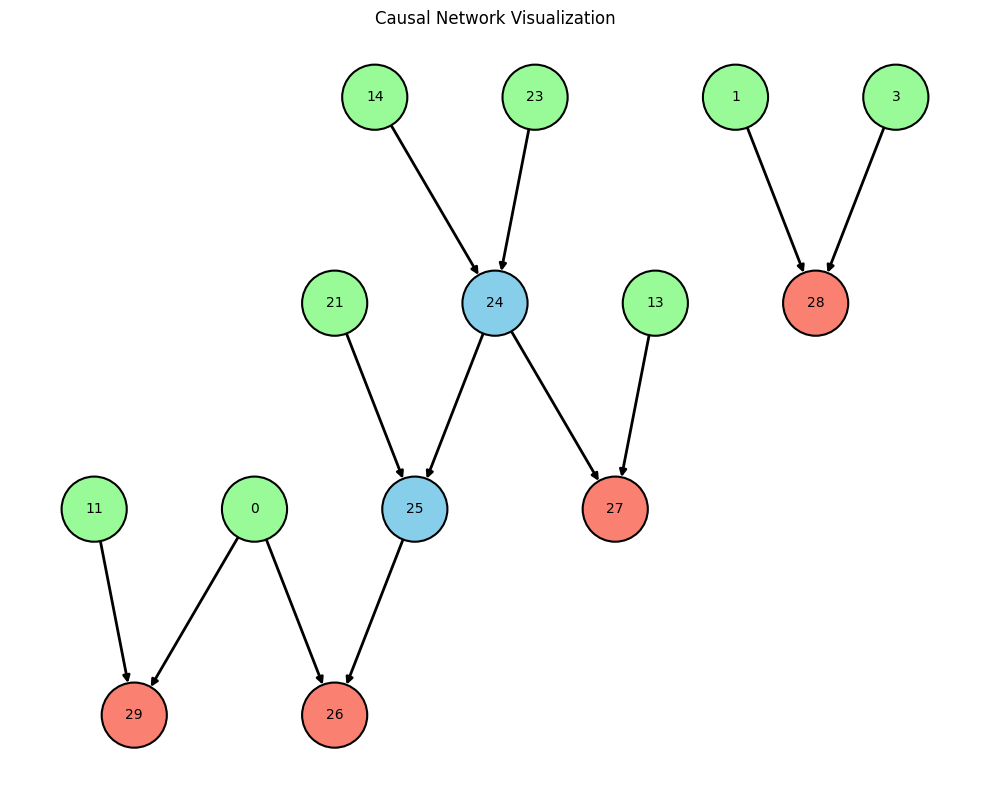

In [65]:
visualize_graph(dag)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network visualisation'}>)

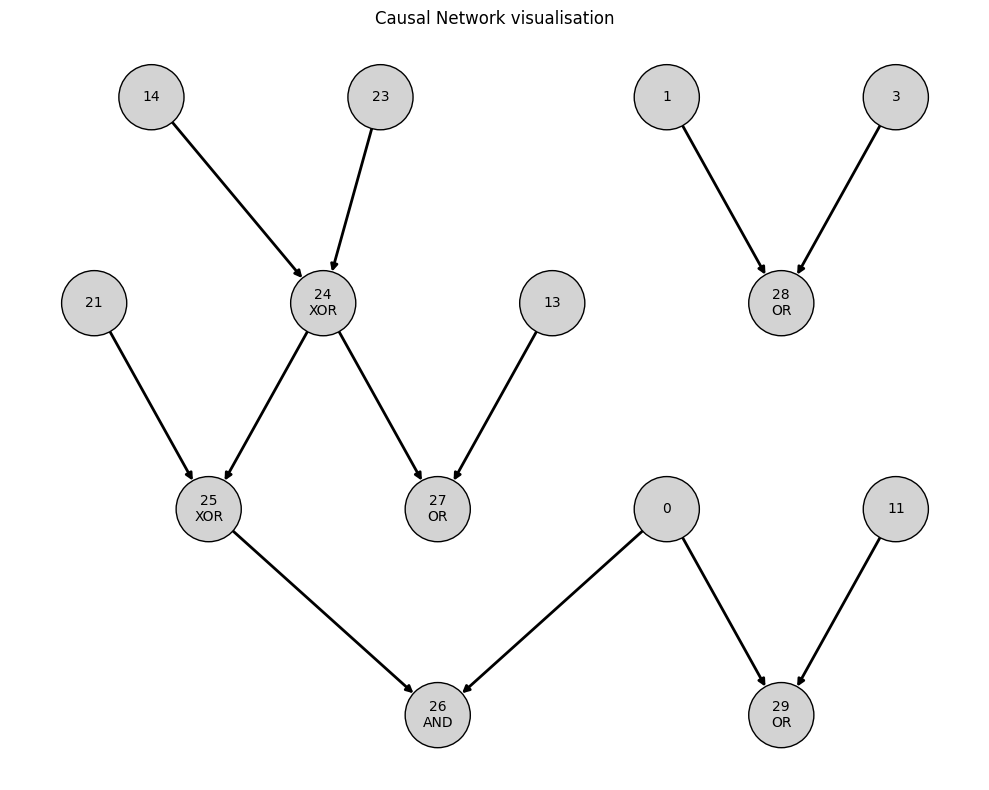

In [66]:
visualize_network_labels(metadata=meta)

In [67]:
from algorithms.benchmark import *

In [68]:
df

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1,1,0,0,0,1,0,1,0,0,...,0,1,1,1,0,1,1,0,1,1
1,0,1,0,1,0,0,1,0,0,0,...,0,0,1,0,1,1,0,1,0,1
2,1,0,0,1,1,0,0,0,1,1,...,0,1,1,1,0,1,1,0,1,1
3,0,1,1,1,1,0,0,0,1,1,...,0,1,1,1,1,0,0,1,0,1
4,0,0,1,1,0,0,1,1,1,1,...,0,1,0,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1,0,1,0,0,1,0,1,1,0,...,0,1,1,1,1,0,0,1,0,1
4996,0,0,1,0,1,0,1,0,1,0,...,0,0,0,1,0,0,0,1,0,0
4997,1,0,1,1,0,1,0,1,1,1,...,0,0,0,1,1,1,1,1,0,1
4998,1,1,1,0,0,1,0,0,1,1,...,0,1,1,0,0,1,1,1,1,1


In [69]:
# learned_dag, score = run_ea(
#     df,
#     # max_parents=2,
#     population_size=30,
#     generations=20,
#     final_greedy=True
# )

In [70]:
df_2.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29'],
      dtype='object')

In [71]:
df_2 = pd.read_csv("data/experiments/RQ1/binary_grid/Data_Graph_0.csv")

In [72]:
learned_dag, score = run_hc(df)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network Visualization'}>)

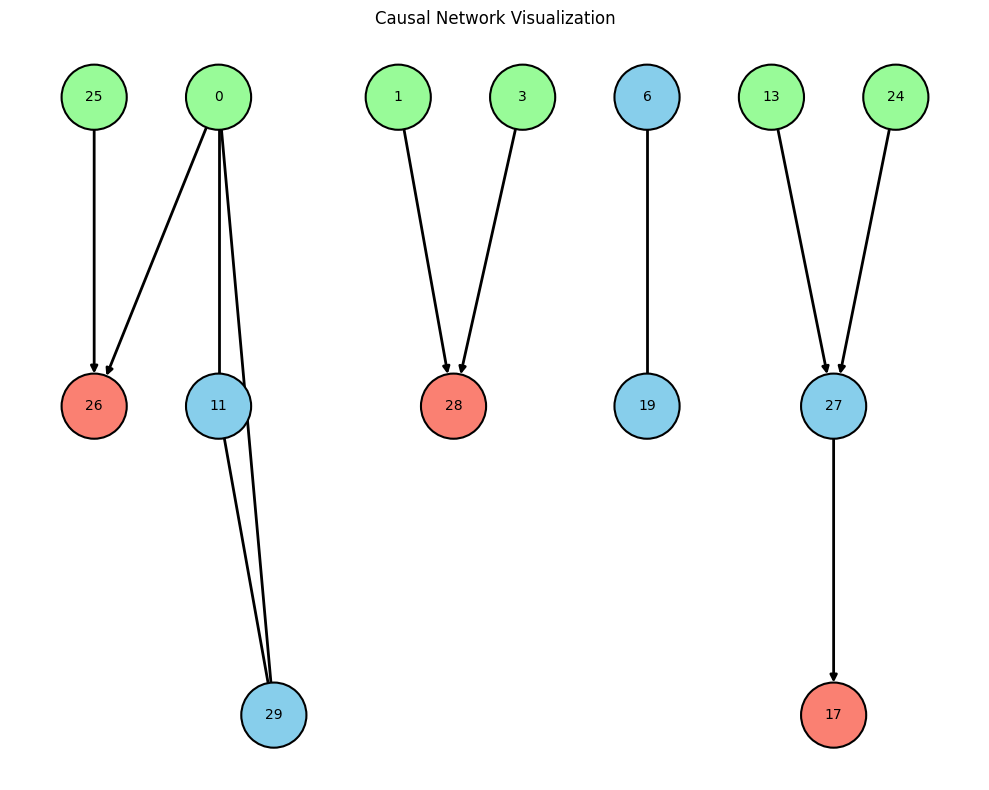

In [73]:
visualize_graph(learned_dag)

In [55]:
from metrics.graph import evaluate_colliders

In [74]:

evaluate_colliders(metadata_df=meta, learned_graph=learned_dag)

{'TP (Found Colliders)': 3,
 'FP (Extra Colliders)': 0,
 'FN (Missing Colliders )': 3,
 'TP (Synergistic Colliders Found)': 0,
 'FN (Missing Synergistic Colliders)': 2,
 'Precision (Collider)': 1.0,
 'Recall (Collider)': 0.5,
 'F1 (Collider)': 0.6666666666666666,
 'Recall (Synergy)': 0.0,
 'TP (Pairwise Colliders Found)': 3,
 'FN (Missing Pairwise Colliders)': 1,
 'Recall (Pairwise)': 0.75}

In [75]:
learned_ea, score_ea = run_ea(
    df,
    population_size=30,
    generations=20,
    final_greedy=True
)

In [76]:
evaluate_colliders(metadata_df=meta, learned_graph=learned_ea)

{'TP (Found Colliders)': 4,
 'FP (Extra Colliders)': 1,
 'FN (Missing Colliders )': 2,
 'TP (Synergistic Colliders Found)': 1,
 'FN (Missing Synergistic Colliders)': 1,
 'Precision (Collider)': 0.8,
 'Recall (Collider)': 0.6666666666666666,
 'F1 (Collider)': 0.7272727272727272,
 'Recall (Synergy)': 0.5,
 'TP (Pairwise Colliders Found)': 3,
 'FN (Missing Pairwise Colliders)': 1,
 'Recall (Pairwise)': 0.75}

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence, Tuple, Literal

import numpy as np
import pandas as pd
import networkx as nx


# ============================================================
# 0) Specs
# ============================================================
@dataclass(frozen=True)
class GateNodeSpec:
    name: int
    parents: Tuple[int, int]
    logic: str


@dataclass(frozen=True)
class BinaryNetworkSpec:
    n_roots: int
    nodes: Tuple[GateNodeSpec, ...]  # generation order (topological among gates)


# ============================================================
# 1) Family scaffold DAG generation (REUSABLE)
# ============================================================
def sample_family_scaffold_dag(
    n_nodes: int,
    family: Literal["er", "ba", "ws"] = "er",
    *,
    seed: int = 0,
    # ER
    p_edge: float = 0.08,
    # BA
    ba_m: int = 4,
    # WS
    ws_k: int = 6,
    ws_beta: float = 0.2,
) -> Tuple[nx.DiGraph, Tuple[int, ...]]:
    """
    Reusable scaffold generator.

    Returns:
      dag  : nx.DiGraph on nodes {0..n_nodes-1} that is guaranteed acyclic
      topo : the topological order used to orient edges

    Families:
      - "er": sample random topo; add forward edges with prob p_edge
      - "ba": build BA undirected; sample topo; orient edges by topo
      - "ws": build WS undirected; sample topo; orient edges by topo
    """
    if n_nodes < 2:
        raise ValueError("n_nodes must be >= 2")

    rng = np.random.default_rng(seed)
    topo = rng.permutation(np.arange(n_nodes)).tolist()
    pos = {int(node): i for i, node in enumerate(topo)}

    if family == "er":
        dag = nx.DiGraph()
        dag.add_nodes_from(range(n_nodes))
        for i in range(n_nodes):
            u = int(topo[i])
            for j in range(i + 1, n_nodes):
                v = int(topo[j])
                if rng.random() < p_edge:
                    dag.add_edge(u, v)
        return dag, tuple(map(int, topo))

    if family == "ba":
        if ba_m < 1:
            raise ValueError("ba_m must be >= 1")
        if ba_m >= n_nodes:
            raise ValueError("ba_m must be < n_nodes")
        G_u = nx.barabasi_albert_graph(n=n_nodes, m=ba_m, seed=seed)
        undirected_edges = list(G_u.edges())

    elif family == "ws":
        if ws_k % 2 != 0:
            raise ValueError("ws_k must be even.")
        if ws_k >= n_nodes:
            raise ValueError("ws_k must be < n_nodes.")
        G_u = nx.watts_strogatz_graph(n=n_nodes, k=ws_k, p=ws_beta, seed=seed)
        undirected_edges = list(G_u.edges())

    else:
        raise ValueError("family must be one of: 'er', 'ba', 'ws'.")

    # Orient undirected edges by topo order to guarantee acyclicity
    dag = nx.DiGraph()
    dag.add_nodes_from(range(n_nodes))
    for a, b in undirected_edges:
        a, b = int(a), int(b)
        u, v = (a, b) if pos[a] < pos[b] else (b, a)
        dag.add_edge(u, v)

    return dag, tuple(map(int, topo))


# ============================================================
# 2) Helpers (logic + logistic)
# ============================================================
def apply_logic(values: np.ndarray, logic: str) -> np.ndarray:
    if logic == "OR":
        return np.any(values, axis=1).astype(int)
    if logic == "AND":
        return np.all(values, axis=1).astype(int)
    if logic == "XOR":
        return np.bitwise_xor.reduce(values, axis=1).astype(int)
    if logic == "NAND":
        return (1 - np.all(values, axis=1)).astype(int)
    if logic == "NOR":
        return (1 - np.any(values, axis=1)).astype(int)
    raise ValueError(f"Unsupported logic: {logic}")


def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))


def sample_logistic_params(
    n_parents: int,
    rng: np.random.Generator,
    weight_scale: float = 1.0,
    bias_scale: float = 0.5,
) -> Tuple[np.ndarray, float]:
    w = rng.normal(0.0, weight_scale, size=n_parents).astype(float)
    b = float(rng.normal(0.0, bias_scale))
    return w, b


def apply_logistic(
    parent_matrix: np.ndarray,
    w: np.ndarray,
    b: float,
    rng: np.random.Generator,
) -> np.ndarray:
    p = sigmoid(b + parent_matrix.astype(float) @ w)
    return (rng.random(parent_matrix.shape[0]) < p).astype(int)


def node_to_str(i: int) -> str:
    return f"{i}"


# ============================================================
# 3) Structure sampling for your gate spec (USES scaffold DAG)
# ============================================================
def sample_gate_dag_structure(
    *,
    n_nodes: int,
    n_gates: int,
    n_xor: int = 0,
    family: Literal["er", "ba", "ws"] = "er",
    # family params
    seed_scaffold: int = 42,
    p_edge: float = 0.08,
    ba_m: int = 4,
    ws_k: int = 6,
    ws_beta: float = 0.2,
    # logic mix
    other_gates: Sequence[str] = ("OR", "AND", "NAND", "NOR"),
    other_gate_probs: Optional[Sequence[float]] = None,
    # constraints
    first_gate_from_roots: bool = True,
    ensure_unshielded: bool = False,
    max_tries_per_gate: int = 200,
    max_resamples: int = 50,
) -> BinaryNetworkSpec:
    """
    Samples a 2-parent gate network on top of a reusable family scaffold DAG.
    """
    if n_nodes < 3:
        raise ValueError("n_nodes must be >= 3.")
    if n_gates < 1:
        raise ValueError("n_gates must be >= 1.")
    if not (0 <= n_xor <= n_gates):
        raise ValueError("n_xor must be between 0 and n_gates.")
    if n_gates >= n_nodes:
        raise ValueError("Need at least 1 root: require n_gates < n_nodes.")

    rng = np.random.default_rng(seed_scaffold)

    def choose_two_parents(dag_so_far: nx.DiGraph, cands: List[int]) -> Tuple[int, int]:
        if len(cands) < 2:
            raise ValueError("Not enough candidates to pick 2 parents.")
        if not ensure_unshielded:
            p0, p1 = rng.choice(cands, size=2, replace=False).tolist()
            return tuple(sorted((int(p0), int(p1))))

        valid_pairs: List[Tuple[int, int]] = []
        cands = list(map(int, cands))
        for i, u in enumerate(cands):
            for v in cands[i + 1:]:
                if not (dag_so_far.has_edge(u, v) or dag_so_far.has_edge(v, u)):
                    valid_pairs.append((u, v))
        if not valid_pairs:
            raise ValueError("No non-adjacent parent pair available.")
        u, v = valid_pairs[int(rng.integers(0, len(valid_pairs)))]
        return tuple(sorted((int(u), int(v))))

    # validate logic probs
    if len(other_gates) == 0 and n_xor < n_gates:
        raise ValueError("other_gates is empty but n_xor < n_gates.")
    if other_gate_probs is not None:
        if len(other_gate_probs) != len(other_gates):
            raise ValueError("other_gate_probs must have same length as other_gates.")
        s = float(np.sum(other_gate_probs))
        if not np.isclose(s, 1.0):
            raise ValueError(f"other_gate_probs must sum to 1.0 (got {s}).")
        if any(p < 0 for p in other_gate_probs):
            raise ValueError("other_gate_probs must be non-negative.")

    for _attempt in range(max_resamples):
        # 1) scaffold DAG + topo (REUSED)
        scaffold, topo = sample_family_scaffold_dag(
            n_nodes=n_nodes,
            family=family,
            seed=int(rng.integers(0, 2**31 - 1)),
            p_edge=p_edge,
            ba_m=ba_m,
            ws_k=ws_k,
            ws_beta=ws_beta,
        )
        topo_list = list(topo)

        # pick gates among nodes with >=2 predecessors in scaffold
        pred_counts = {v: scaffold.in_degree(v) for v in range(n_nodes)}
        eligible = [v for v in range(n_nodes) if pred_counts[v] >= 2]
        if len(eligible) < n_gates:
            continue

        gates = set(rng.choice(eligible, size=n_gates, replace=False).tolist())
        roots = [v for v in range(n_nodes) if v not in gates]

        # build logic labels (exact XOR count)
        logics: List[str] = ["XOR"] * n_xor
        n_rest = n_gates - n_xor
        if n_rest > 0:
            sampled = rng.choice(other_gates, size=n_rest, replace=True, p=other_gate_probs)
            logics.extend(sampled.tolist())
        logics = rng.permutation(np.array(logics, dtype=object)).tolist()

        # enforce 2-parent structure consistent with topo (parents must be earlier)
        dag_so_far = nx.DiGraph()
        dag_so_far.add_nodes_from(range(n_nodes))

        available: set[int] = set()
        nodes: List[GateNodeSpec] = []
        logic_idx = 0
        ok = True

        for v in topo_list:
            v = int(v)
            if v in roots:
                available.add(v)
                continue

            if len(available) < 2:
                ok = False
                break

            # prefer scaffold parents that are already available
            cand_parents = [int(u) for u in scaffold.predecessors(v) if int(u) in available]

            if logic_idx == 0 and first_gate_from_roots:
                base_pool = [u for u in available if u in roots]
                if len(base_pool) < 2:
                    base_pool = list(available)
            else:
                base_pool = list(available)

            pool = cand_parents if len(cand_parents) >= 2 else base_pool

            picked: Optional[Tuple[int, int]] = None
            for _ in range(max_tries_per_gate):
                try:
                    if len(pool) < 2:
                        pool = base_pool
                    picked = choose_two_parents(dag_so_far, pool)
                    break
                except ValueError:
                    pool = base_pool

            if picked is None:
                ok = False
                break

            p0, p1 = picked
            nodes.append(GateNodeSpec(name=v, parents=(p0, p1), logic=str(logics[logic_idx])))
            logic_idx += 1

            dag_so_far.add_edge(p0, v)
            dag_so_far.add_edge(p1, v)
            available.add(v)

        if (not ok) or (logic_idx != n_gates):
            continue

        # relabel roots first then gates in generation order
        roots_sorted = sorted(roots)
        gates_sorted = [n.name for n in nodes]
        new_order = roots_sorted + gates_sorted
        relabel = {old: new for new, old in enumerate(new_order)}

        relabeled_nodes: List[GateNodeSpec] = []
        for gn in nodes:
            relabeled_nodes.append(
                GateNodeSpec(
                    name=relabel[int(gn.name)],
                    parents=tuple(sorted((relabel[int(gn.parents[0])], relabel[int(gn.parents[1])]))),
                    logic=gn.logic,
                )
            )

        return BinaryNetworkSpec(n_roots=len(roots_sorted), nodes=tuple(relabeled_nodes))

    raise ValueError(
        "Could not sample a feasible structure under current settings. "
        "Try increasing n_nodes, lowering n_gates, or adjusting family params."
    )


# ============================================================
# 4) Simulator (logic/logistic/mixed) – unchanged
# ============================================================
def simulate_binary_from_gate_spec(
    spec: BinaryNetworkSpec,
    n_samples: int,
    *,
    root_p: float = 0.5,
    p_noise: float = 0.0,
    seed_data: int = 42,
    seed_params: Optional[int] = None,
    gate_model: Literal["logic", "logistic", "mixed"] = "logic",
    p_logistic: float = 0.5,
    weight_scale: float = 1.0,
    bias_scale: float = 0.5,
) -> Tuple[pd.DataFrame, nx.DiGraph, Dict[str, Dict[str, Any]], pd.DataFrame]:
    if not (0.0 <= root_p <= 1.0):
        raise ValueError("root_p must be in [0, 1].")
    if not (0.0 <= p_noise <= 1.0):
        raise ValueError("p_noise must be in [0, 1].")
    if gate_model == "mixed" and not (0.0 <= p_logistic <= 1.0):
        raise ValueError("p_logistic must be in [0, 1].")

    rng_data = np.random.default_rng(seed_data)
    rng_params = np.random.default_rng(seed_params if seed_params is not None else seed_data + 1)

    n_roots = int(spec.n_roots)
    Xr = (rng_data.random((n_samples, n_roots)) < root_p).astype(int)
    data: Dict[int, np.ndarray] = {i: Xr[:, i] for i in range(n_roots)}

    dag = nx.DiGraph()
    dag.add_nodes_from(range(n_roots))

    gate_info_int: Dict[int, Dict[str, Any]] = {}

    meta_combs: List[List[int]] = []
    meta_type: List[str] = []
    meta_model: List[str] = []
    meta_w: List[Optional[List[float]]] = []
    meta_b: List[Optional[float]] = []

    def choose_gate_model() -> str:
        if gate_model == "logic":
            return "logic"
        if gate_model == "logistic":
            return "logistic"
        return "logistic" if (rng_params.random() < p_logistic) else "logic"

    for gn in spec.nodes:
        v = int(gn.name)
        p0, p1 = map(int, gn.parents)
        parents = [p0, p1]

        P = np.stack([data[p0], data[p1]], axis=1)  # (n_samples, 2)
        model_here = choose_gate_model()

        if model_here == "logic":
            out = apply_logic(P, gn.logic)
            w_list, b_val = None, None
            gate_info_int[v] = {"model": "logic", "parents": parents, "logic": gn.logic}

        elif model_here == "logistic":
            w, b = sample_logistic_params(
                n_parents=2, rng=rng_params, weight_scale=weight_scale, bias_scale=bias_scale
            )
            out = apply_logistic(P, w=w, b=b, rng=rng_data)
            w_list, b_val = w.tolist(), float(b)
            gate_info_int[v] = {
                "model": "logistic",
                "parents": parents,
                "w": w_list,
                "b": b_val,
                "logic_tag": gn.logic,
            }
        else:
            raise ValueError(f"Unknown gate model: {model_here}")

        if p_noise > 0:
            flip = rng_data.random(n_samples) < p_noise
            out = out.copy()
            out[flip] = 1 - out[flip]

        data[v] = out
        dag.add_node(v)
        dag.add_edge(p0, v)
        dag.add_edge(p1, v)

        meta_combs.append([p0, p1, v])
        meta_type.append(gn.logic)
        meta_model.append(model_here)
        meta_w.append(w_list)
        meta_b.append(b_val)

    df = pd.DataFrame({node_to_str(k): data[k] for k in sorted(data.keys())})
    dag_str = nx.relabel_nodes(dag, node_to_str, copy=True)

    gate_info: Dict[str, Dict[str, Any]] = {}
    for k, info in gate_info_int.items():
        info2 = dict(info)
        info2["parents"] = [node_to_str(int(u)) for u in info2.get("parents", [])]
        gate_info[node_to_str(int(k))] = info2

    metadata = pd.DataFrame(
        {
            "Combs": [[node_to_str(a), node_to_str(b), node_to_str(c)] for a, b, c in meta_combs],
            "Type": meta_type,
            "GateModel": meta_model,
            "w": meta_w,
            "b": meta_b,
        }
    )

    return df, dag_str, gate_info, metadata


# ============================================================
# Thin class wrapper
# ============================================================
class BinaryDataset:
    def __init__(self):
        pass

    def sample_structure_network(self, **kwargs) -> BinaryNetworkSpec:
        return sample_gate_dag_structure(**kwargs)

    def generate_from_structure(self, spec: BinaryNetworkSpec, **kwargs):
        return simulate_binary_from_gate_spec(spec, **kwargs)


# ============================================================
# Example
# ============================================================
if __name__ == "__main__":
    ds = BinaryDataset()

    spec = ds.sample_structure_network(
        n_nodes=30,
        n_gates=20,
        n_xor=6,
        family="ws",
        ws_k=6,
        ws_beta=0.2,
        seed_scaffold=123,
        ensure_unshielded=True,
    )

    df, dag, gate_info, meta = ds.generate_from_structure(
        spec,
        n_samples=5000,
        gate_model="mixed",
        p_logistic=0.3,
        root_p=0.5,
        p_noise=0.05,
        seed_data=777,
        seed_params=888,
    )

    print(df.head())
    print(meta.head())
    print("Nodes:", dag.number_of_nodes(), "Edges:", dag.number_of_edges())


,Combs,Type,GateModel,w,b
0,"[3, 9, 10]",AND,logic,None,NaN
1,"[2, 3, 11]",OR,logistic,"[-0.6035446301667122, 1.1610531964172013]",0.449036
2,"[2, 5, 12]",OR,logic,None,NaN
3,"[7, 8, 13]",OR,logic,None,NaN
4,"[3, 6, 14]",XOR,logic,None,NaN
5,"[8, 9, 15]",OR,logic,None,NaN
6,"[2, 3, 16]",AND,logic,None,NaN
7,"[0, 16, 17]",XOR,logic,None,NaN
8,"[4, 5, 18]",OR,logistic,"[0.003779688153919042, -1.6407064834579732]",-0.670544
9,"[0, 9, 19]",OR,logic,None,NaN
